# 05 实战：MNIST 手写数字识别

本 Notebook 是一个**完整的端到端项目**，覆盖：
- 数据加载与预处理
- CNN 模型设计
- 训练 + 验证循环
- 测试集评估 & 各类别准确率
- 错误样本可视化
- 模型导出

**对应文档**: `docs/07-practice/01-mnist-classifier.md`

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

device = torch.device(
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f'使用设备: {device}')

# Windows 系统推荐使用微软雅黑
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
# 解决保存图像时负号'-'显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False 
print(f'使用中文字体: Windows 微软雅黑 ')


使用设备: cpu
使用中文字体: Windows 微软雅黑 


## 1. 数据加载

训练集: 54,000  验证集: 6,000  测试集: 10,000


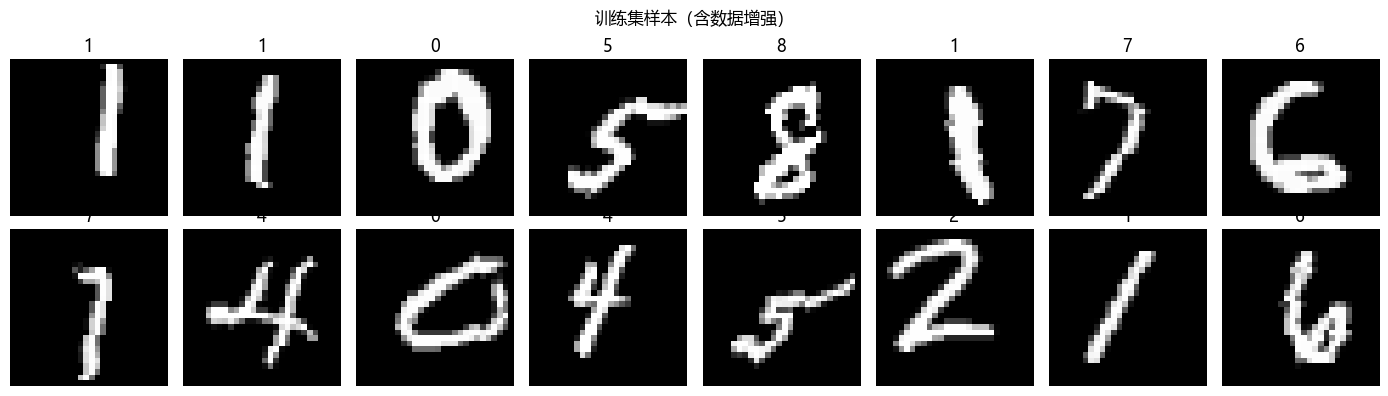

In [2]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,)),
])

# 数据增强版本（训练集）
aug_transform = T.Compose([
    T.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,)),
])

full_train = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=aug_transform)
test_set   = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

# 从训练集中分出 10% 作为验证集
train_size = int(0.9 * len(full_train))
val_size   = len(full_train) - train_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)

print(f'训练集: {len(train_set):,}  验证集: {len(val_set):,}  测试集: {len(test_set):,}')

# 可视化样本
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i, 0].numpy(), cmap='gray')
    ax.set_title(labels[i].item())
    ax.axis('off')
plt.suptitle('训练集样本（含数据增强）')
plt.tight_layout()
plt.show()

## 2. 模型定义

In [3]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            # 第一卷积块: 1×28×28 → 32×14×14
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            # 第二卷积块: 32×14×14 → 64×7×7
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            # 第三卷积块: 64×7×7 → 128×7×7
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 全局平均池化 → 128×1×1
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.conv(x))


model = CNNClassifier().to(device)
print(model)
print(f'\n总参数量: {sum(p.numel() for p in model.parameters()):,}')

CNNClassifier(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_fe

## 3. 训练

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2,
    steps_per_epoch=len(train_loader), epochs=10
)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_acc, best_state = 0.0, None

for epoch in range(1, 11):
    # 训练
    model.train()
    t_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        t_loss += loss.item()

    # 验证
    model.eval()
    v_loss, correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            v_loss  += criterion(logits, labels).item()
            correct += (logits.argmax(1) == labels).sum().item()

    v_acc = correct / len(val_set)
    t_loss /= len(train_loader)
    v_loss /= len(val_loader)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if v_acc > best_acc:
        best_acc   = v_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch:2d}/10 | loss={t_loss:.4f} | val_loss={v_loss:.4f} | val_acc={v_acc:.4f}')

print(f'\n最佳验证准确率: {best_acc:.4f}')

## 4. 测试集评估

In [ ]:
# 加载最佳权重
model.load_state_dict(best_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
test_acc   = (all_preds == all_labels).float().mean().item()
print(f'测试集准确率: {test_acc:.4f}')

# 各类别准确率
print('\n各类别准确率:')
for c in range(10):
    mask = (all_labels == c)
    acc  = (all_preds[mask] == c).float().mean().item()
    bar  = '█' * int(acc * 20)
    print(f'  数字 {c}: {acc:.4f} {bar}')

## 5. 错误样本可视化

In [ ]:
# 找出预测错误的样本
wrong_idx  = (all_preds != all_labels).nonzero(as_tuple=True)[0][:16]
test_imgs  = test_set.data[wrong_idx]  # 原始未归一化图像

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(wrong_idx):
        idx = wrong_idx[i].item()
        ax.imshow(test_imgs[i].numpy(), cmap='gray')
        ax.set_title(f'真:{all_labels[idx].item()} 预:{all_preds[idx].item()}',
                     color='red', fontsize=8)
    ax.axis('off')

plt.suptitle('预测错误的样本')
plt.tight_layout()
plt.show()

## 练习题

1. **简单**: 去掉 `BatchNorm2d`，重新训练，对比准确率和收敛速度
2. **中等**: 将 CNN 替换为纯 MLP（`nn.Flatten` + 全连接层），对比参数量和准确率
3. **挑战**: 将本项目迁移到 Fashion-MNIST 数据集（替换 `torchvision.datasets.MNIST` 为 `FashionMNIST`），观察性能差异，并思考原因